<a href="https://colab.research.google.com/github/thaissanchesroque/Projetos/blob/main/Pre_Processamento_dos_dados_Segunda_Etapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MÓDULO 15 - Exercício**
# Análise  - A segunda etapa da Pré Modelagem

# 1) O primeiro exercício é o de salvar a base que criaram na atividade do módulo anterior em csv e abrir ela neste arquivo.
Igual fizemos no início do módulo atual no início da primeira aula.

In [137]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px

In [138]:
from google.colab import drive
import pandas as pd
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

caminho = '/content/drive/MyDrive/ColabNotebooks/CHURN_CREDIT_MOD14.csv'

df = pd.read_csv(caminho, sep=';', low_memory=False)

df.head()

,CustomerId,Sobrenome,Credit_Score,Pais,Genero,Idade,Tempo_Credito,Balance,Qtd_Produtos,Possui_Cartao,Membro_Ativo,Salario_Anual,Churn
0,15813451,Fleetwood-Smith,677,Spain,Male,18.0,5,134796.87,2,1.0,0.0,114858.9,0.0
1,15641688,Collier,644,Spain,Female,18.0,7,0.00,1,0.0,1.0,74564.41,0.0
2,15757821,Burgess,641,Spain,Male,18.0,1,0.00,2,0.0,1.0,41542.95,0.0
3,15673180,Onyekaozulu,826,Spain,Male,18.0,2,0.00,2,0.0,1.0,16245.25,0.0
4,15664543,Tuan,774,Spain,Female,18.0,1,185891.54,1,1.0,0.0,175072.41,0.0


# 2) Comece pela análise univariada:

A) Utilize a função describe no seu dataframe, veja os insights que consegue retirar.

B) Já é possível identificar variáveis com possíveis outliers? Se sim, quais?

C) Plot gráficos que considerar importante para completar sua análise univariada. (Lembrando que sua variável preditora é o churn). Não se esqueça de trazer insights de cada gráfico plotado. Utilize pelo menos 4 variáveis distintas.

D) Verifique se os dados das variáveis Booleanas são balanceados ou não.

In [139]:
estatisticas = df.describe().T

estatisticas = estatisticas.rename(columns={
    'count': 'Quantidade',
    'mean': 'Média',
    'std': 'Desvio Padrão',
    'min': 'Mínimo',
    '25%': '1º Quartil',
    '50%': 'Mediana',
    '75%': '3º Quartil',
    'max': 'Máximo'
})

estatisticas = estatisticas.round(2)
estatisticas.style.format('{:.2f}')

,Quantidade,Média,Desvio Padrão,Mínimo,1º Quartil,Mediana,3º Quartil,Máximo
CustomerId,100000.00,15691924.80,71384.67,15565701.00,15632977.00,15690164.00,15756668.00,15815690.00
Credit_Score,100000.00,656.48,80.28,350.00,597.00,659.00,710.00,850.00
Idade,99794.00,38.13,8.82,18.00,32.00,37.00,42.00,92.00
Tempo_Credito,100000.00,5.03,2.81,0.00,3.00,5.00,7.00,10.00
Balance,100000.00,55543.79,62784.05,0.00,0.00,0.00,119839.70,250898.09
Qtd_Produtos,100000.00,1.55,0.55,1.00,1.00,2.00,2.00,4.00
Possui_Cartao,100000.00,0.76,0.43,0.00,1.00,1.00,1.00,1.00
Membro_Ativo,100000.00,0.50,0.50,0.00,0.00,0.00,1.00,1.00
Churn,99911.00,0.21,0.41,0.00,0.00,0.00,0.00,1.00


*A) A análise descritiva permite compreender o comportamento inicial das variáveis numéricas. Observando média, mediana, desvio padrão e quartis, já é possível identificar variáveis com grande dispersão e levantar hipóteses sobre a existência de valores extremos que deverão ser investigados nas próximas etapas.*

*B) Pela análise do resumo estatístico, já existem indícios de possíveis outliers em algumas variáveis numéricas, principalmente aquelas que apresentam grande diferença entre o valor máximo e o terceiro quartil (75%) ou elevado desvio padrão. Entretanto, a confirmação será realizada por meio dos boxplots.*

*C) Variável 1 - Idade*

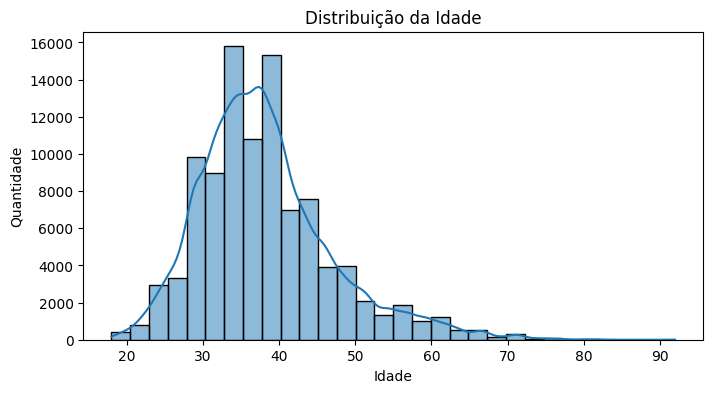

In [140]:
plt.figure(figsize=(8,4))

sns.histplot(df['Idade'], bins=30, kde=True)

plt.title('Distribuição da Idade')
plt.xlabel('Idade')
plt.ylabel('Quantidade')

plt.show()

*A maior concentração de clientes encontra-se aproximadamente entre 30 e 45 anos. Também existem clientes com idade mais elevada, indicando uma distribuição relativamente dispersa.*

*C) Variável 2 - CreditScore*

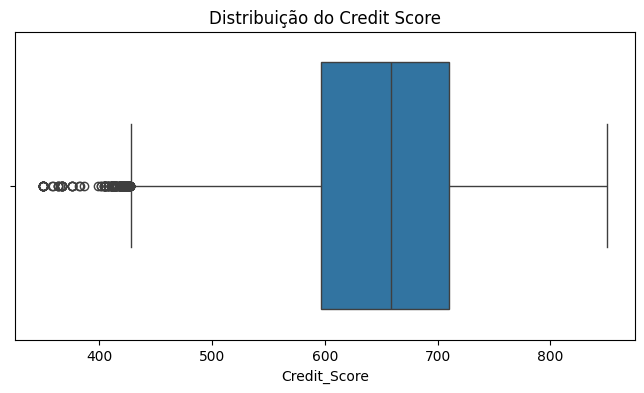

In [141]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df['Credit_Score'])

plt.title('Distribuição do Credit Score')

plt.show()

*O Credit Score apresenta distribuição relativamente concentrada, porém existem alguns valores extremos que deverão ser avaliados durante o tratamento de outliers.*

*C) Variável 3 - Balance*

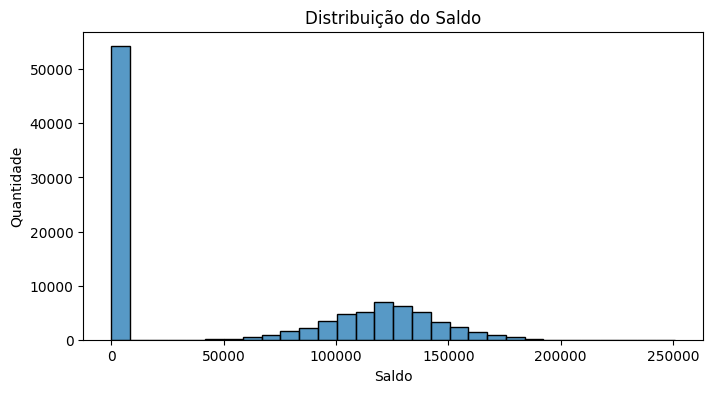

In [142]:
plt.figure(figsize=(8,4))

sns.histplot(df['Balance'], bins=30)

plt.title('Distribuição do Saldo')
plt.xlabel('Saldo')
plt.ylabel('Quantidade')

plt.show()

*O saldo apresenta grande dispersão entre os clientes. Também é possível observar um número considerável de clientes com saldo igual a zero, indicando diferentes perfis financeiros.*

*C) Variável 4 - Distribuição do Salário*

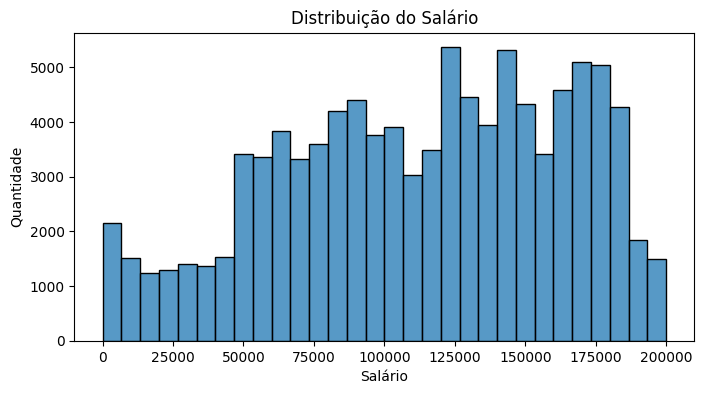

In [143]:
plt.figure(figsize=(8,4))

df['Salario_Anual'] = pd.to_numeric(df['Salario_Anual'], errors='coerce')

sns.histplot(df['Salario_Anual'], bins=30)

plt.title('Distribuição do Salário')
plt.xlabel('Salário')
plt.ylabel('Quantidade')

plt.show()

*D) Variáveis Boleanas*


Possui_Cartao


,Percentual (%)
Possui_Cartao,
1.0,75.5
0.0,24.5


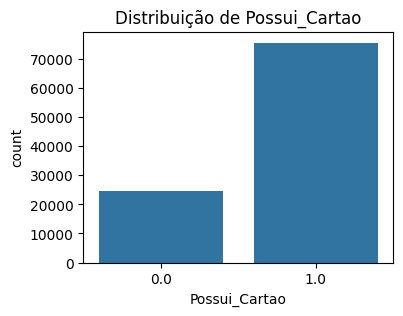


Membro_Ativo


,Percentual (%)
Membro_Ativo,
0.0,50.3
1.0,49.7


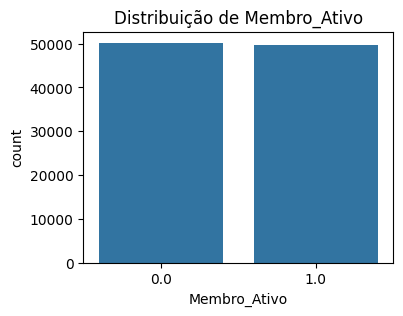


Churn


,Percentual (%)
Churn,
0.0,78.9
1.0,21.1


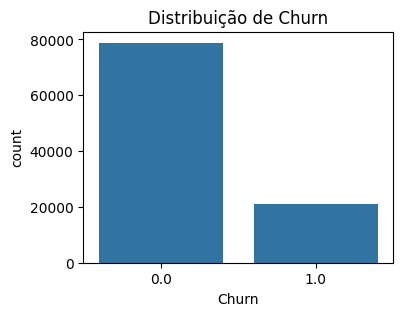

Churn,faixa_idade,% Não Churn,% Churn
0,Até 30,91.7,8.3
1,31-45,83.8,16.2
2,46-60,43.5,56.5
3,60+,65.8,34.2


In [144]:
variaveis_booleanas = [
    'Possui_Cartao',
    'Membro_Ativo',
    'Churn'
]

for coluna in variaveis_booleanas:
    percentual = (
        df[coluna]
        .value_counts(normalize=True)
        .mul(100)
        .rename('Percentual (%)')
        .round(1)
    )

    print(f'\n{coluna}')
    display(percentual)
    plt.figure(figsize=(4,3))
    sns.countplot(data=df, x=coluna)
    plt.title(f'Distribuição de {coluna}')
    plt.show()


df['faixa_idade'] = pd.cut(
    df['Idade'],
    bins=[0, 30, 45, 60, 100],
    labels=['Até 30', '31-45', '46-60', '60+']
)
tabela_idade_churn = pd.crosstab(
    df['faixa_idade'],
    df['Churn'],
    normalize='index'
).mul(100).round(1)


tabela_idade_churn = tabela_idade_churn.rename(columns={0:'% Não Churn', 1:'% Churn'})
tabela_idade_churn = tabela_idade_churn.reset_index()
tabela_idade_churn = tabela_idade_churn.rename(columns={'index': 'Faixa de Idade'})
display(tabela_idade_churn)

*A análise por faixa etária indica que clientes entre 46 e 60 anos possuem maior taxa de churn, esse público representa o maior risco de evasão e deve ser investigado com prioridade. As variáveis booleanas apresentam diferentes níveis de balanceamento. Membro_Ativo possui distribuição equilibrada, enquanto Possui_Cartao e principalmente Churn apresentam desbalanceamento.*

# 3) Identifique e trate as colunas que contém outliers.
Caso opte por mante-los ou altera-los justifique sua escolha.


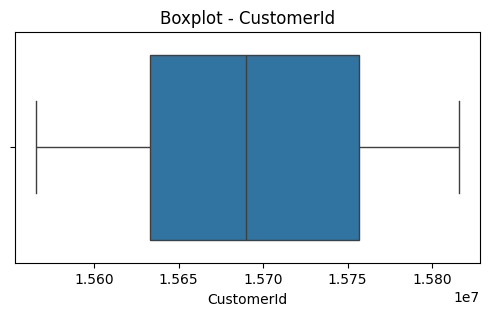

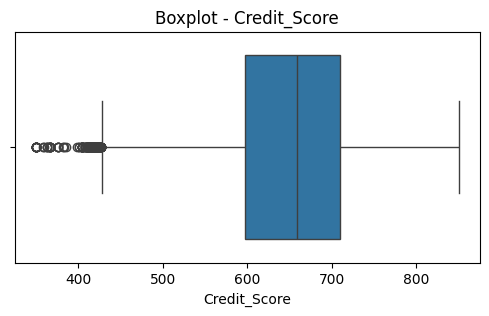

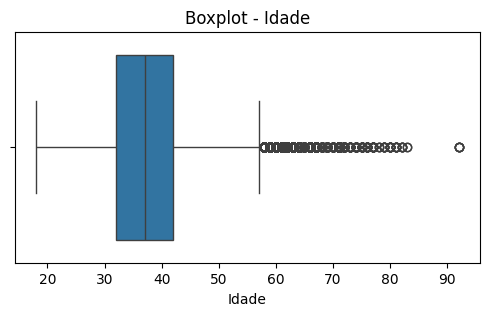

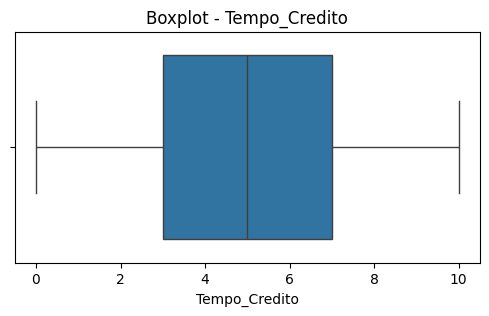

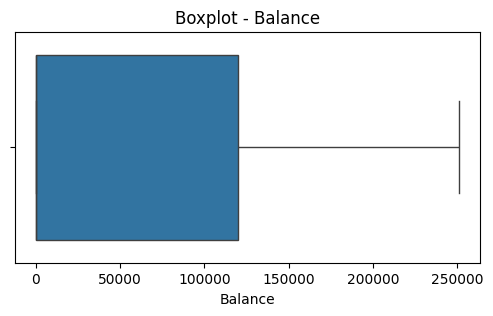

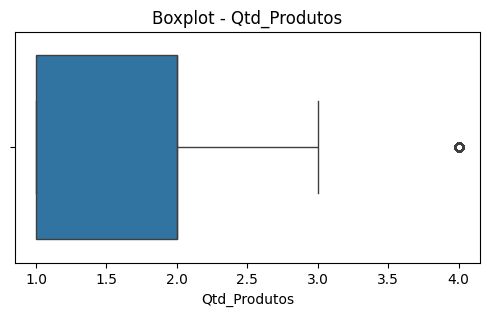

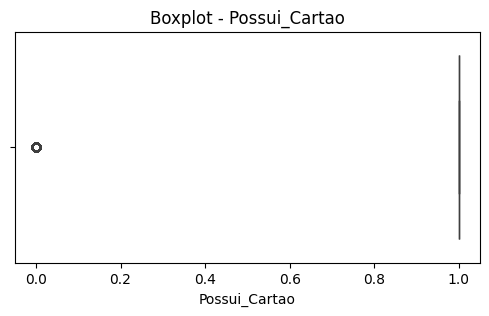

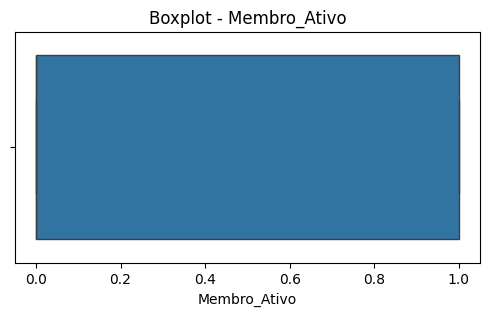

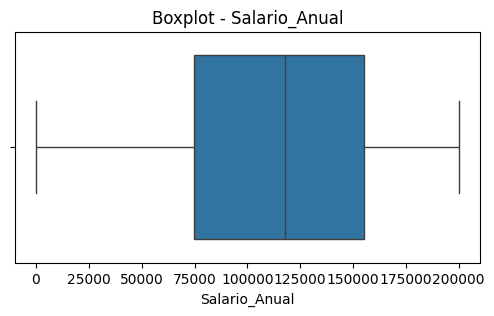

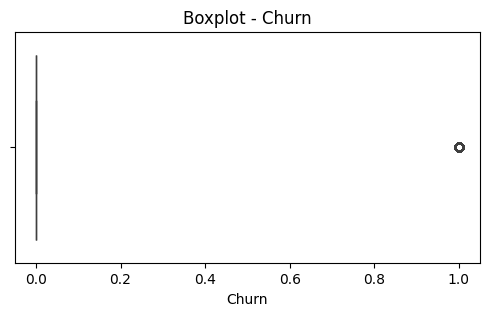

,Quantidade,Percentual (%),Limite inferior,Limite superior
CustomerId,0.0,0.00,15447440.50,15942204.50
Credit_Score,150.0,0.15,427.50,879.50
Idade,3852.0,3.85,17.00,57.00
Tempo_Credito,0.0,0.00,-3.00,13.00
Balance,0.0,0.00,-179759.56,299599.26
Qtd_Produtos,305.0,0.30,-0.50,3.50
Possui_Cartao,24464.0,24.46,1.00,1.00
Membro_Ativo,0.0,0.00,-1.50,2.50
Salario_Anual,0.0,0.00,-46699.79,276671.41
Churn,21096.0,21.10,0.00,0.00


In [145]:
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

outliers = {}

for coluna in colunas_numericas:

    Q1 = df[coluna].quantile(0.25)
    Q3 = df[coluna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    qtd_outliers = df[
        (df[coluna] < limite_inferior) |
        (df[coluna] > limite_superior)
    ].shape[0]

    percentual = (qtd_outliers / len(df)) * 100

    outliers[coluna] = {
        'Quantidade': qtd_outliers,
        'Percentual (%)': round(percentual, 2),
        'Limite inferior': round(limite_inferior,2),
        'Limite superior': round(limite_superior,2)
    }


for coluna in colunas_numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[coluna])
    plt.title(f'Boxplot - {coluna}')
    plt.show()


pd.DataFrame(outliers).T

*Os outliers foram identificados utilizando o método do IQR. Entretanto, optou-se por mantê-los na base, pois representam características reais dos clientes, como alto saldo bancário, idade elevada ou maior renda anual. Como o objetivo é prever churn, remover esses registros poderia eliminar perfis importantes e reduzir a capacidade de generalização do modelo. Assim, os outliers foram apenas identificados e documentados para acompanhamento nas etapas de modelagem.*

# 4) Realize a etapa da análise bivariada:
A) Questione pelo menos 5 informações e traga as respostas utilizando visuais gráficos e insights.


B) Quais variáveis você acredita serem as mais importantes para esse projetos relacionadas a variável Churn?

A 1) Como o churn se comporta entre diferentes faixas etárias?

Churn,% Não Churn,% Churn
faixa_idade,,
Até 30,91.7,8.3
31-45,83.8,16.2
46-60,43.5,56.5
60+,65.8,34.2


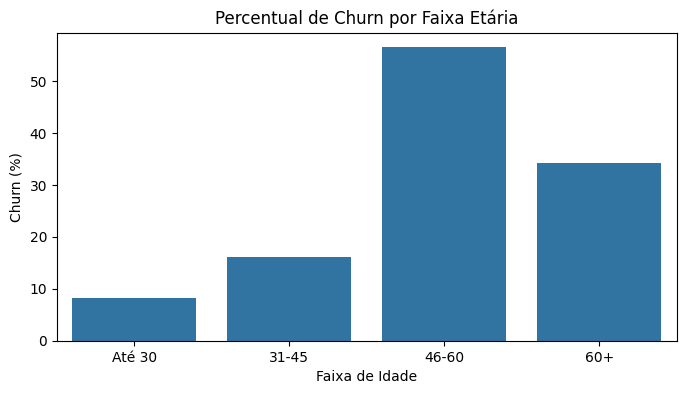

In [146]:
df['faixa_idade'] = pd.cut(
    df['Idade'],
    bins=[0, 30, 45, 60, 100],
    labels=['Até 30', '31-45', '46-60', '60+']
)

tabela_idade_churn = pd.crosstab(
    df['faixa_idade'],
    df['Churn'],
    normalize='index'
).mul(100).round(1)

tabela_idade_churn = tabela_idade_churn.rename(
    columns={0:'% Não Churn', 1:'% Churn'}
)

display(tabela_idade_churn)


plt.figure(figsize=(8,4))

sns.barplot(
    data=tabela_idade_churn.reset_index(),
    x='faixa_idade',
    y='% Churn'
)

plt.title('Percentual de Churn por Faixa Etária')
plt.xlabel('Faixa de Idade')
plt.ylabel('Churn (%)')

plt.show()

*Clientes entre 46 e 60 anos apresentam maior percentual de churn, indicando maior concentração de evasão nesse grupo.*

A 2) Como o saldo dos clientes varia entre os países?

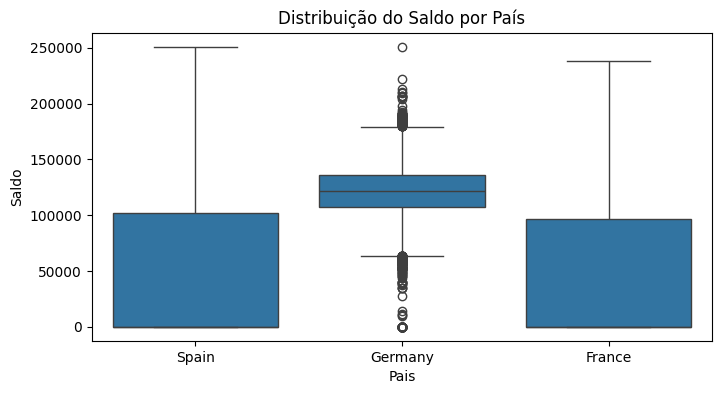

In [147]:
df['Pais'] = df['Pais'].str.title()
df['Pais'] = df['Pais'].replace({
    'Germani': 'Germany'
})
df['Pais'].value_counts()


plt.figure(figsize=(8,4))

sns.boxplot(
    data=df,
x='Pais',
    y='Balance'
)

plt.title('Distribuição do Saldo por País')
plt.xlabel('Pais')
plt.ylabel('Saldo')

plt.show()

*A Alemanha concentra os maiores valores médios de saldo, enquanto Espanha e França apresentam maior dispersão.*

A 3) Existe relação entre salário anual e saldo dos clientes?

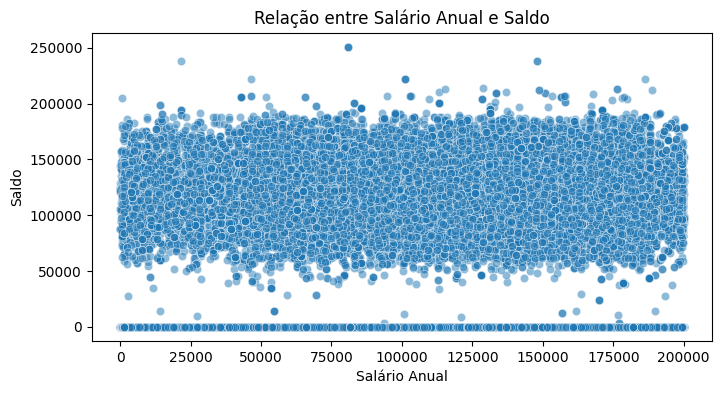

In [148]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df,
    x='Salario_Anual',
    y='Balance',
    alpha=0.5
)

plt.title('Relação entre Salário Anual e Saldo')
plt.xlabel('Salário Anual')
plt.ylabel('Saldo')

plt.show()

*Não foi identificada uma relação clara entre salário e saldo, indicando que a renda não explica sozinha o comportamento financeiro dos clientes.*

A 4) Como o comportamento de churn se distribui entre clientes que possuem e que não possuem cartão?

In [149]:
df['Possui_Cartao'] = df['Possui_Cartao'].replace({
    0.0: 'NAO',
    1.0: 'SIM'
})
tabela_cartao_churn = pd.crosstab(
    df['Possui_Cartao'],
    df['Churn'],
    normalize='index'
).mul(100).round(1)

tabela_cartao_churn.columns = ['% Não Churn', '% Churn']

display(tabela_cartao_churn)

,% Não Churn,% Churn
Possui_Cartao,,
NAO,77.3,22.7
SIM,79.4,20.6


*Clientes sem cartão apresentam uma taxa de churn um pouco maior (22,7%) comparados aos clientes com cartão (20,6%). A diferença não é extremamente alta, mas indica que possuir cartão pode estar associado a um maior vínculo com a empresa.*

A 5) Como a distribuição de clientes varia entre os gêneros?

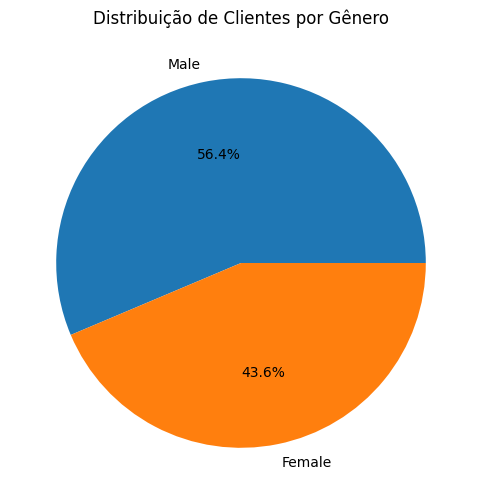

In [152]:
genero = df['Genero'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    genero,
    labels=genero.index,
    autopct='%1.1f%%'
)

plt.title('Distribuição de Clientes por Gênero')

plt.show()

*O público masculino representando 56,4% dos clientes enquanto o público feminino corresponde a 43,6%.*

B 5) As variáveis que apresentam maior relação com o **Churn** são **Membro_Ativo, Possui_Cartao e Idade**, pois ajudam a entender o comportamento e o nível de relacionamento do cliente com a empresa. A variável **Membro_Ativo** é importante porque clientes que possuem maior interação tendem a permanecer mais tempo, enquanto clientes menos ativos podem apresentar maior chance de cancelamento. A variável **Possui_Cartao** também apresenta uma relação com o churn, pois clientes sem cartão tiveram uma taxa de cancelamento maior (**22,7%**) comparados aos clientes com cartão (**20,6%**), indicando que o cartão pode estar associado a um maior vínculo com a empresa. A variável **Idade** pode influenciar o comportamento dos clientes, já que diferentes faixas etárias podem ter necessidades e hábitos de consumo diferentes. A variável **Gênero** possui menor impacto analisando sozinha, mas pode ajudar a encontrar padrões quando combinada com outras informações do cliente. Portanto, essas variáveis podem ajudar a identificar clientes com maior risco de cancelamento e contribuir para a criação de ações de retenção mais eficientes.
